In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки для воспроизводимости
np.random.seed(42)

# Стиль графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Загрузка данных
df = pd.read_csv('machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df = df.sort_index()

print(f"Размер датасета: {df.shape}")
print(f"Период данных: от {df.index.min()} до {df.index.max()}")
print(f"Количество пропущенных значений: {df['value'].isnull().sum()}")

df.head()

Размер датасета: (22695, 1)
Период данных: от 2013-12-02 21:15:00 до 2014-02-19 15:25:00
Количество пропущенных значений: 0


,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


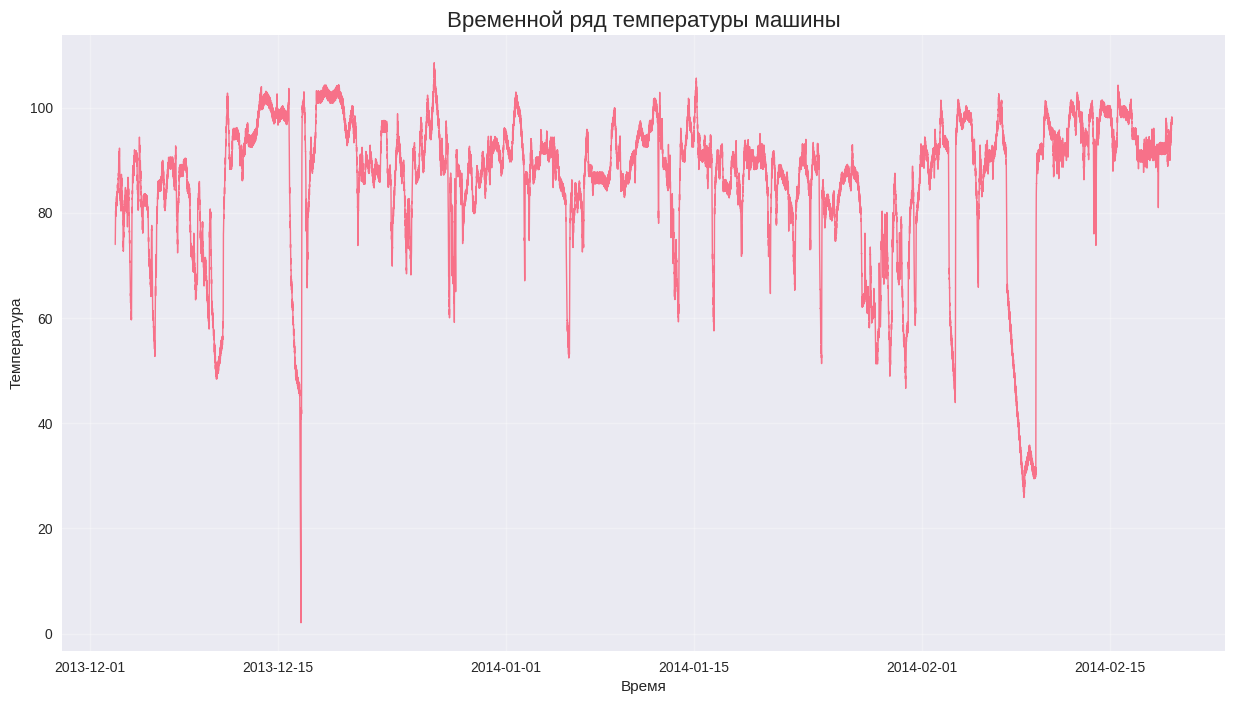

In [ ]:
# Визуализация исходного ряда
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['value'], linewidth=1)
plt.title('Временной ряд температуры машины', fontsize=16)
plt.xlabel('Время')
plt.ylabel('Температура')
plt.grid(True, alpha=0.3)
plt.show()

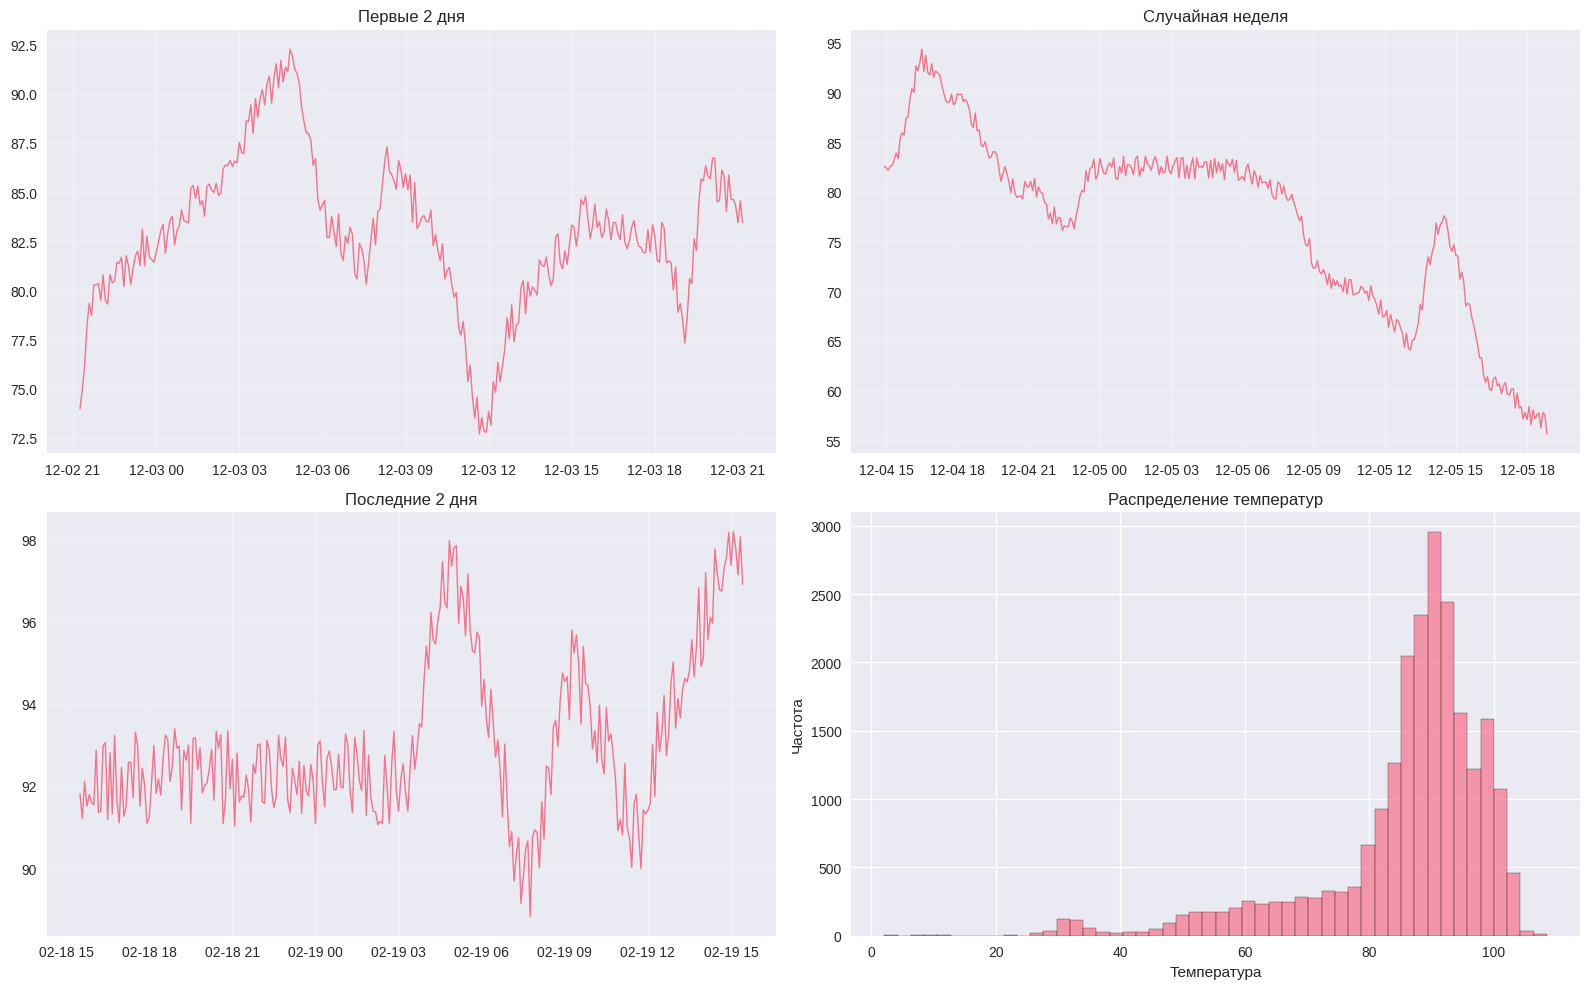

In [ ]:
# Детальная визуализация разных периодов
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Первые 2 дня
axes[0,0].plot(df.index[:288], df['value'][:288], linewidth=1)
axes[0,0].set_title('Первые 2 дня')
axes[0,0].grid(True, alpha=0.3)

# Случайная неделя
start_idx = 500
axes[0,1].plot(df.index[start_idx:start_idx+336], df['value'][start_idx:start_idx+336], linewidth=1)
axes[0,1].set_title('Случайная неделя')
axes[0,1].grid(True, alpha=0.3)

# Последние 2 дня
axes[1,0].plot(df.index[-288:], df['value'][-288:], linewidth=1)
axes[1,0].set_title('Последние 2 дня')
axes[1,0].grid(True, alpha=0.3)

# Распределение значений
axes[1,1].hist(df['value'], bins=50, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Распределение температур')
axes[1,1].set_xlabel('Температура')
axes[1,1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

Анализ временного ряда
Из визуализации можно сделать следующие наблюдения:

Тренд: В ряде наблюдается сложный нелинейный тренд с периодами роста и падения температуры

Сезонность: Возможна суточная сезонность, но она не явно выражена

Стационарность: Ряд явно нестационарен - среднее значение и дисперсия меняются со временем

Выбросы: Есть резкие изменения температуры, которые могут указывать на аномалии

In [ ]:
# Train/test split (80/20)
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")
print(f"Test period: от {test.index.min()} до {test.index.max()}")

Train size: 18156
Test size: 4539
Test period: от 2014-02-03 21:15:00 до 2014-02-19 15:25:00


In [ ]:
# Выбор метрики - использую MAE, RMSE и MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

**Бейзлайн модели**

In [ ]:
# Наивный прогноз (последнее значение)
naive_forecast = np.array([train['value'].iloc[-1]] * len(test))

# Скользящее среднее (окно 24 часа - сутки)
window_size = 24
rolling_mean = train['value'].rolling(window=window_size).mean().iloc[-1]
rolling_forecast = np.array([rolling_mean] * len(test))

# Метрики для бейзлайнов
naive_mae, naive_rmse, naive_mape = calculate_metrics(test['value'], naive_forecast)
rolling_mae, rolling_rmse, rolling_mape = calculate_metrics(test['value'], rolling_forecast)

print("Наивный прогноз:")
print(f"MAE: {naive_mae:.4f}, RMSE: {naive_rmse:.4f}, MAPE: {naive_mape:.2f}%")

print("\nСкользящее среднее:")
print(f"MAE: {rolling_mae:.4f}, RMSE: {rolling_rmse:.4f}, MAPE: {rolling_mape:.2f}%")

Наивный прогноз:
MAE: 12.0013, RMSE: 22.4795, MAPE: 26.38%

Скользящее среднее:
MAE: 12.2124, RMSE: 22.6687, MAPE: 26.70%


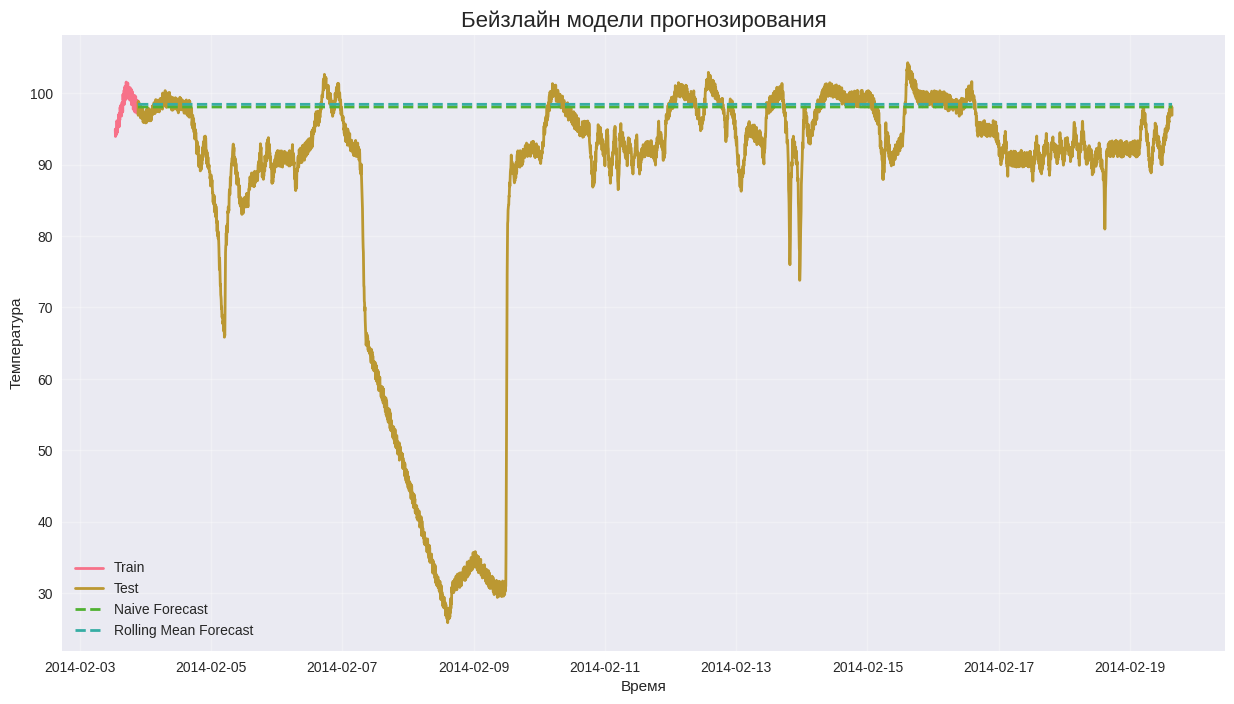

In [ ]:
# Визуализация бейзлайн моделей
plt.figure(figsize=(15, 8))

plt.plot(train.index[-100:], train['value'][-100:], label='Train', linewidth=2)
plt.plot(test.index, test['value'], label='Test', linewidth=2)
plt.plot(test.index, naive_forecast, label='Naive Forecast', linestyle='--', linewidth=2)
plt.plot(test.index, rolling_forecast, label='Rolling Mean Forecast', linestyle='--', linewidth=2)

plt.title('Бейзлайн модели прогнозирования', fontsize=16)
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Статистический анализ и ARIMA/SARIMA**

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Тест Дики-Фуллера на стационарность
def adf_test(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

    if result[1] <= 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не отвергаем H0)")

print("Тест Дики-Фуллера для исходного ряда:")
adf_test(train['value'])

Тест Дики-Фуллера для исходного ряда:
ADF Statistic: -7.837632292919011
p-value: 6.055169390972298e-12
Critical Values:
	1%: -3.4307107007505078
	5%: -2.8616994161499894
	10%: -2.56685485301784
Ряд стационарен (отвергаем H0)


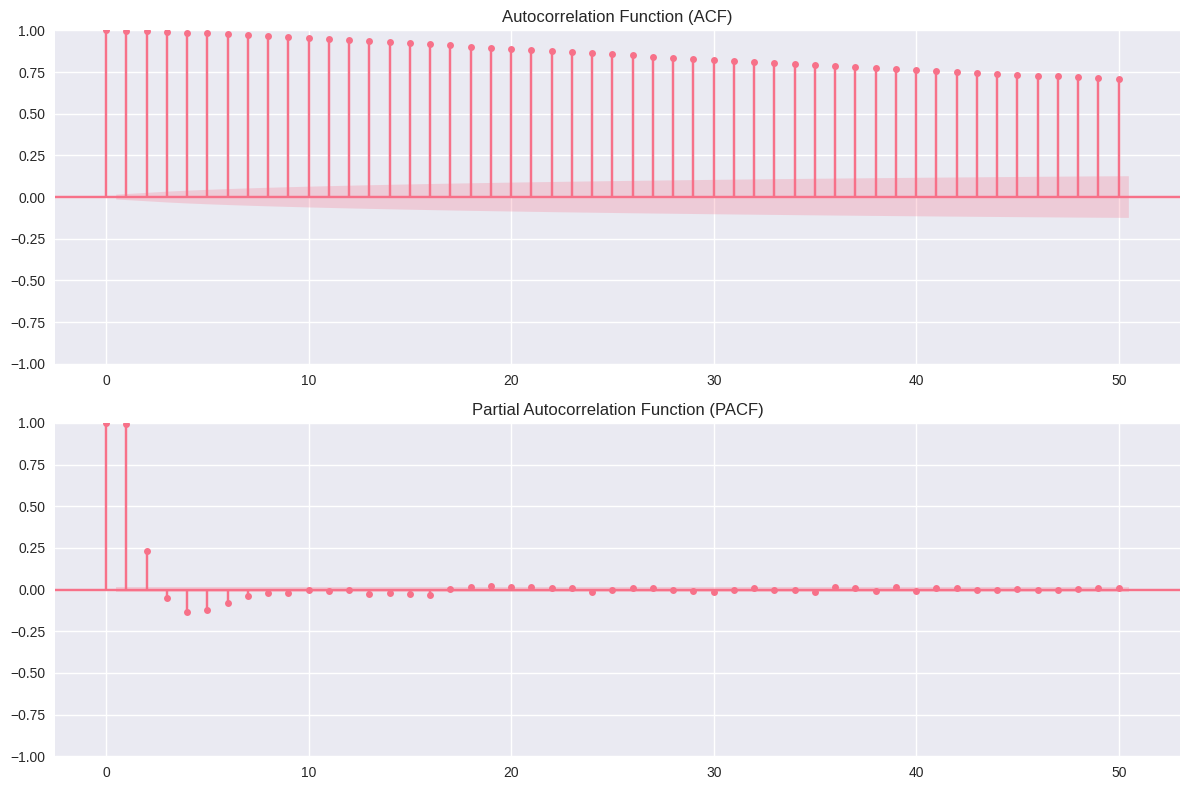

In [ ]:
# ACF и PACF исходного ряда
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(train['value'], ax=axes[0], lags=50)
axes[0].set_title('Autocorrelation Function (ACF)')
plot_pacf(train['value'], ax=axes[1], lags=50)
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

**Анализ ACF/PACF**

ACF: Медленно убывает, что подтверждает нестационарность

PACF: Резко обрывается после нескольких лагов

Сезонность: Не наблюдается явной сезонной компоненты

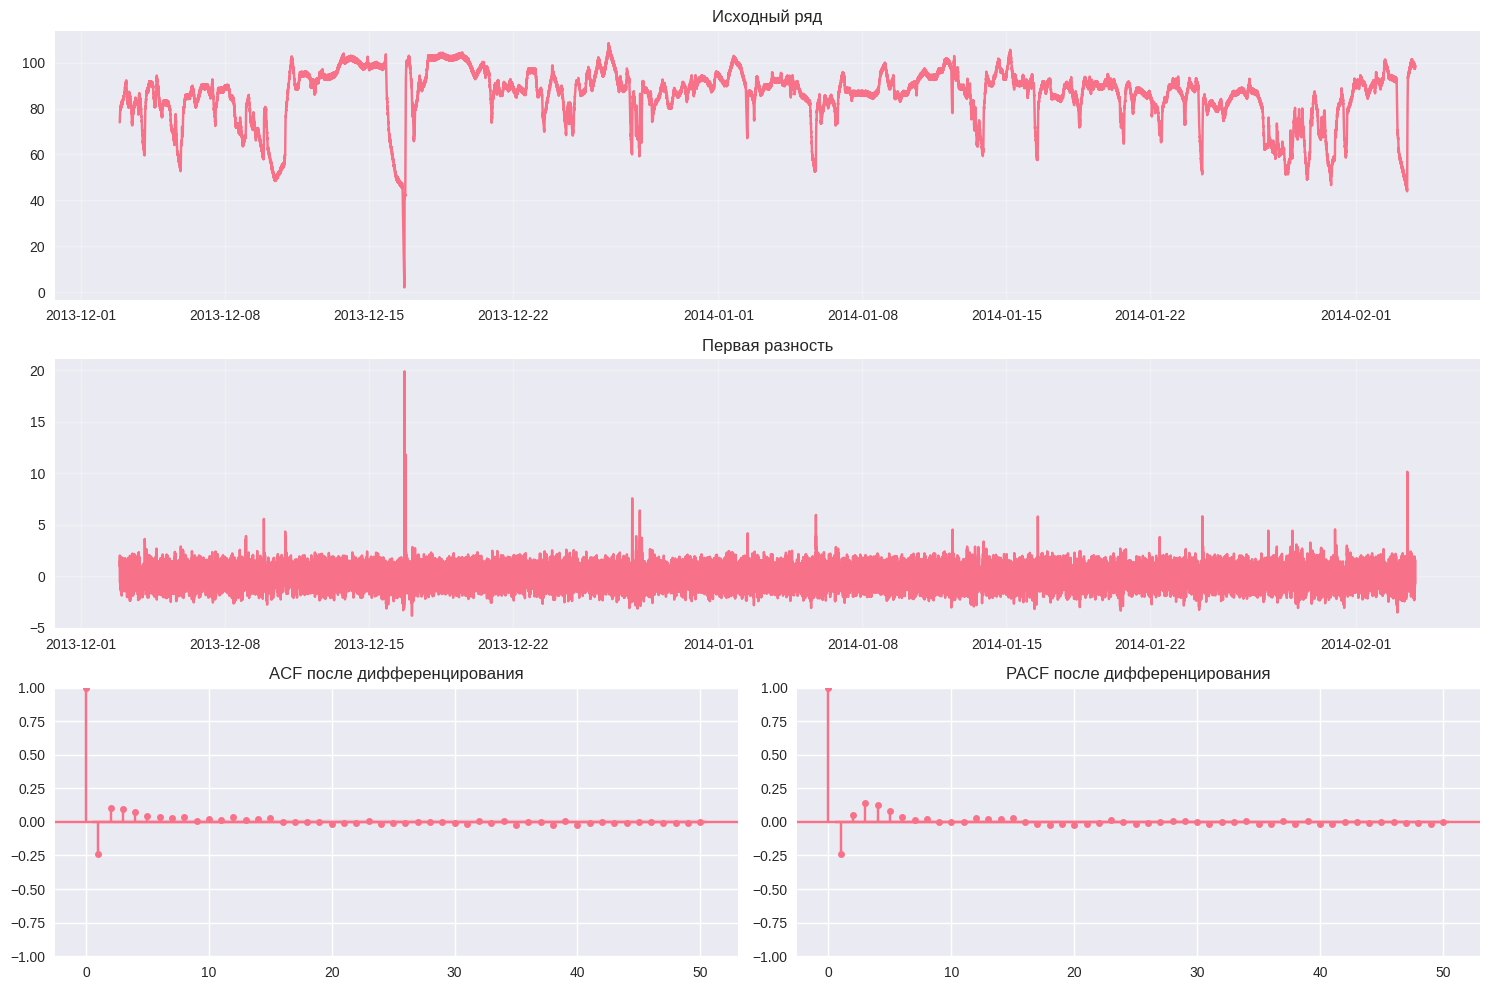

In [ ]:
# Дифференцирование для придания стационарности
train_diff = train['value'].diff().dropna()

plt.figure(figsize=(15, 10))

# Исходный ряд
plt.subplot(3, 1, 1)
plt.plot(train.index, train['value'])
plt.title('Исходный ряд')
plt.grid(True, alpha=0.3)

# Первая разность
plt.subplot(3, 1, 2)
plt.plot(train.index[1:], train_diff)
plt.title('Первая разность')
plt.grid(True, alpha=0.3)

# ACF/PACF после дифференцирования
plt.subplot(3, 2, 5)
plot_acf(train_diff, ax=plt.gca(), lags=50)
plt.title('ACF после дифференцирования')

plt.subplot(3, 2, 6)
plot_pacf(train_diff, ax=plt.gca(), lags=50)
plt.title('PACF после дифференцирования')

plt.tight_layout()
plt.show()

In [ ]:
# Тест Дики-Фуллера после дифференцирования
print("Тест Дики-Фуллера после дифференцирования:")
adf_test(train_diff)

Тест Дики-Фуллера после дифференцирования:
ADF Statistic: -26.21231038117668
p-value: 0.0
Critical Values:
	1%: -3.4307107007505078
	5%: -2.8616994161499894
	10%: -2.56685485301784
Ряд стационарен (отвергаем H0)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from itertools import product

# Проверка на дубликаты временных меток
print(f"Дубликаты в train: {train.index.duplicated().sum()}")
print(f"Дубликаты в test: {test.index.duplicated().sum()}")

# Удаляю дубликаты если есть
train_clean = train[~train.index.duplicated(keep='first')]
test_clean = test[~test.index.duplicated(keep='first')]

print(f"Train после очистки: {len(train_clean)}")
print(f"Test после очистки: {len(test_clean)}")

# Создаю новый индекс с правильной частотой
train_freq = train_clean.asfreq('5T')
# Заполняю пропуски если они появятся
train_freq['value'] = train_freq['value'].interpolate(method='linear')

print(f"Train с частотой: {len(train_freq)}")

Дубликаты в train: 12
Дубликаты в test: 0
Train после очистки: 18144
Test после очистки: 4539
Train с частотой: 18144


In [ ]:
# Поиск оптимальных параметров ARIMA
def find_best_arima(train_data, p_range, d_range, q_range):
    best_aic = np.inf
    best_order = None
    best_model = None

    for p, d, q in product(p_range, d_range, q_range):
        try:
            model = ARIMA(train_data, order=(p, d, q))
            fitted_model = model.fit()
            if fitted_model.aic < best_aic:
                best_aic = fitted_model.aic
                best_order = (p, d, q)
                best_model = fitted_model
            print(f"ARIMA({p},{d},{q}) - AIC: {fitted_model.aic:.2f}")
        except Exception as e:
            print(f"ARIMA({p},{d},{q}) - ошибка: {e}")
            continue

    return best_order, best_model, best_aic

# Поиск параметров
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)

print("Поиск оптимальных параметров ARIMA...")
best_order, best_model, best_aic = find_best_arima(train_freq['value'], p_range, d_range, q_range)
print(f"\nЛучшие параметры ARIMA: {best_order}")
print(f"Лучший AIC: {best_aic:.2f}")

Поиск оптимальных параметров ARIMA...
ARIMA(0,0,0) - AIC: 141371.65
ARIMA(0,0,1) - AIC: 119055.55
ARIMA(0,0,2) - AIC: 103040.71
ARIMA(0,1,0) - AIC: 54414.85
ARIMA(0,1,1) - AIC: 53556.99
ARIMA(0,1,2) - AIC: 53133.11
ARIMA(1,0,0) - AIC: 54389.01
ARIMA(1,0,1) - AIC: 53545.45
ARIMA(1,0,2) - AIC: 53117.20
ARIMA(1,1,0) - AIC: 53375.59
ARIMA(1,1,1) - AIC: 53354.27
ARIMA(1,1,2) - AIC: 52557.98
ARIMA(2,0,0) - AIC: 53364.10
ARIMA(2,0,1) - AIC: 53341.74
ARIMA(2,0,2) - AIC: 52511.80
ARIMA(2,1,0) - AIC: 53329.45
ARIMA(2,1,1) - AIC: 52750.74
ARIMA(2,1,2) - AIC: 52559.90

Лучшие параметры ARIMA: (2, 0, 2)
Лучший AIC: 52511.80


In [ ]:
# Прогноз ARIMA
arima_forecast = best_model.forecast(steps=len(test_clean))

# Метрики ARIMA
arima_mae, arima_rmse, arima_mape = calculate_metrics(test_clean['value'], arima_forecast)

print("ARIMA модель:")
print(f"MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.2f}%")

ARIMA модель:
MAE: 13.4649, RMSE: 19.3103, MAPE: 24.95%


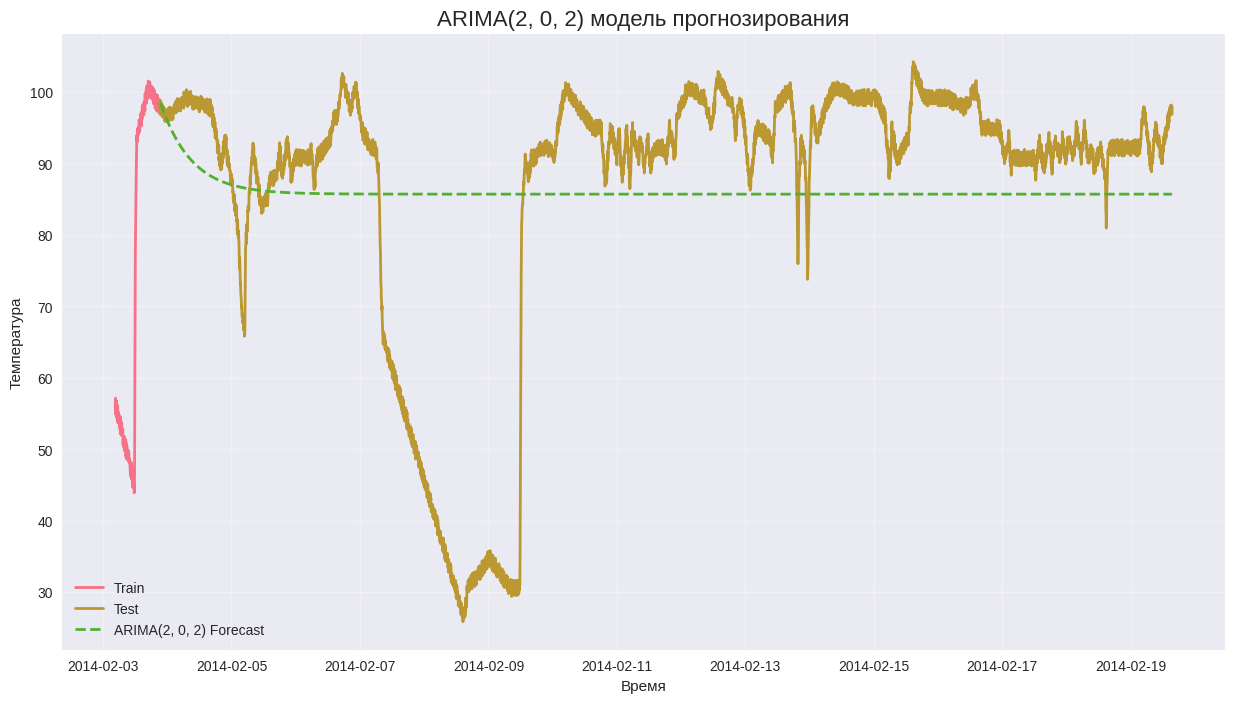

In [ ]:
# Визуализация ARIMA
plt.figure(figsize=(15, 8))

# Использую очищенные данные для визуализации
plot_start = max(0, len(train_clean) - 200)

plt.plot(train_clean.index[plot_start:], train_clean['value'][plot_start:], label='Train', linewidth=2)
plt.plot(test_clean.index, test_clean['value'], label='Test', linewidth=2)
plt.plot(test_clean.index, arima_forecast, label=f'ARIMA{best_order} Forecast', linestyle='--', linewidth=2)

plt.title(f'ARIMA{best_order} модель прогнозирования', fontsize=16)
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

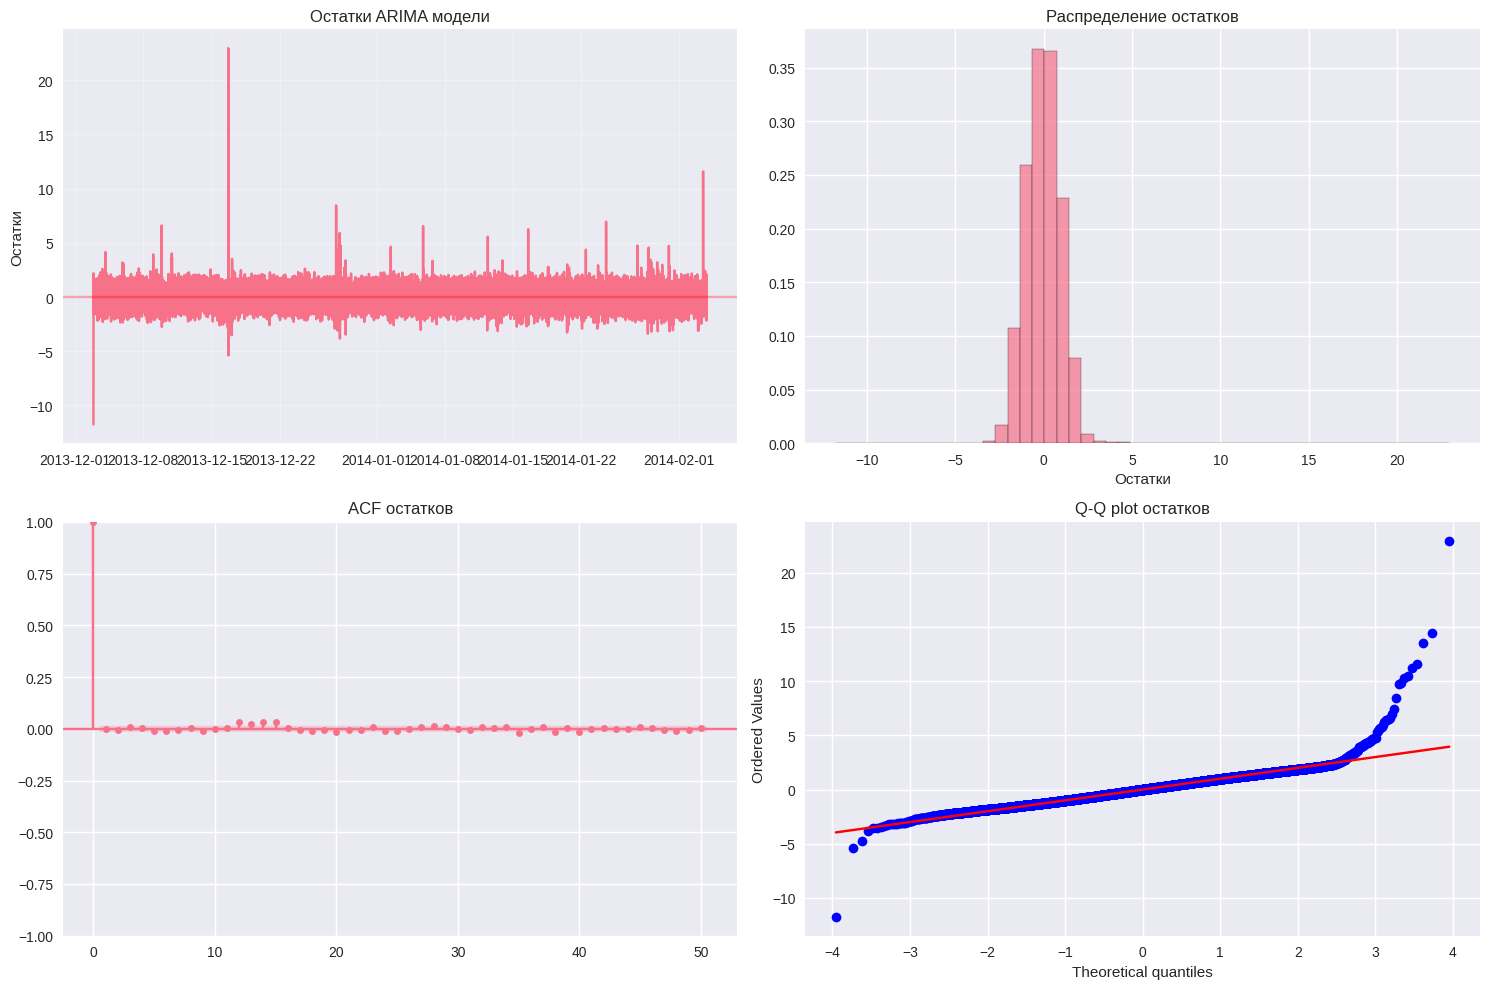

Тест Шапиро-Вилка на нормальность: p-value = 0.0000
Остатки не нормально распределены

Тест Льюнга-Бокса на автокорреляцию:
p-value: 0.5841
Нет автокорреляции в остатках


In [ ]:
# Анализ остатков ARIMA
residuals = best_model.resid

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Остатки временной ряд
axes[0, 0].plot(residuals.index, residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='-', alpha=0.3)
axes[0, 0].set_title('Остатки ARIMA модели')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].grid(True, alpha=0.3)

# Распределение остатков
axes[0, 1].hist(residuals, bins=50, alpha=0.7, edgecolor='black', density=True)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].set_xlabel('Остатки')

# ACF остатков
plot_acf(residuals, ax=axes[1, 0], lags=50)
axes[1, 0].set_title('ACF остатков')

# Тест на нормальность остатков
from scipy.stats import shapiro, norm
import scipy.stats as stats

# QQ-plot
stats.probplot(residuals.dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot остатков')

plt.tight_layout()
plt.show()

# Статистические тесты
shapiro_stat, shapiro_p = shapiro(residuals.dropna())
print(f"Тест Шапиро-Вилка на нормальность: p-value = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("Остатки нормально распределены")
else:
    print("Остатки не нормально распределены")

# Тест на автокорреляцию остатков
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals.dropna(), lags=10, return_df=True)
print(f"\nТест Льюнга-Бокса:")
print(f"p-value: {lb_test['lb_pvalue'].iloc[-1]:.4f}")
if lb_test['lb_pvalue'].iloc[-1] > 0.05:
    print("Нет автокорреляции в остатках")
else:
    print("Есть автокорреляция в остатках")

**Классические ML модели**

In [2]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Feature Engineering (расширенная версия)
def create_features(df, max_lags=24, rolling_windows=[6, 12, 24]):
    features_df = df.copy()

    # Лаги
    for lag in range(1, max_lags + 1):
        features_df[f'lag_{lag}'] = features_df['value'].shift(lag)

    # Скользящие статистики
    for window in rolling_windows:
        features_df[f'rolling_mean_{window}'] = features_df['value'].rolling(window=window, min_periods=1).mean()
        features_df[f'rolling_std_{window}'] = features_df['value'].rolling(window=window, min_periods=1).std()
        features_df[f'rolling_min_{window}'] = features_df['value'].rolling(window=window, min_periods=1).min()
        features_df[f'rolling_max_{window}'] = features_df['value'].rolling(window=window, min_periods=1).max()

    # Экспоненциальное сглаживание
    for alpha in [0.3, 0.5, 0.7]:
        features_df[f'ewm_{alpha}'] = features_df['value'].ewm(alpha=alpha).mean()

    # Признаки времени
    features_df['hour'] = features_df.index.hour
    features_df['dayofweek'] = features_df.index.dayofweek
    features_df['dayofyear'] = features_df.index.dayofyear
    features_df['week'] = features_df.index.isocalendar().week
    features_df['quarter'] = features_df.index.quarter
    features_df['is_weekend'] = (features_df.index.dayofweek >= 5).astype(int)

    # Тригонометрические преобразования для циклических признаков
    features_df['hour_sin'] = np.sin(2 * np.pi * features_df['hour'] / 24)
    features_df['hour_cos'] = np.cos(2 * np.pi * features_df['hour'] / 24)
    features_df['dayofweek_sin'] = np.sin(2 * np.pi * features_df['dayofweek'] / 7)
    features_df['dayofweek_cos'] = np.cos(2 * np.pi * features_df['dayofweek'] / 7)
    features_df['month_sin'] = np.sin(2 * np.pi * features_df.index.month / 12)
    features_df['month_cos'] = np.cos(2 * np.pi * features_df.index.month / 12)

    return features_df

# Создание признаков
features_df = create_features(df)
features_df = features_df.dropna()

# Разделение на train/test с признаками
split_point = int(len(features_df) * 0.8)
train_features = features_df.iloc[:split_point]
test_features = features_df.iloc[split_point:]

# Целевая переменная
X_train = train_features.drop('value', axis=1)
y_train = train_features['value']
X_test = test_features.drop('value', axis=1)
y_test = test_features['value']

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Количество признаков: {X_train.shape[1]}")

NameError: name 'df' is not defined

In [ ]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Случайный лес
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=10,
    min_samples_split=5
)
rf_model.fit(X_train_scaled, y_train)

# Градиентный бустинг
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1
)
gb_model.fit(X_train_scaled, y_train)

# Прогнозы
rf_forecast = rf_model.predict(X_test_scaled)
gb_forecast = gb_model.predict(X_test_scaled)

# Метрики
rf_mae, rf_rmse, rf_mape = calculate_metrics(y_test, rf_forecast)
gb_mae, gb_rmse, gb_mape = calculate_metrics(y_test, gb_forecast)

print("Random Forest:")
print(f"MAE: {rf_mae:.4f}, RMSE: {rf_rmse:.4f}, MAPE: {rf_mape:.2f}%")

print("\nGradient Boosting:")
print(f"MAE: {gb_mae:.4f}, RMSE: {gb_rmse:.4f}, MAPE: {gb_mape:.2f}%")

Random Forest:
MAE: 0.3850, RMSE: 1.1063, MAPE: 1.03%

Gradient Boosting:
MAE: 0.1568, RMSE: 0.3687, MAPE: 0.35%


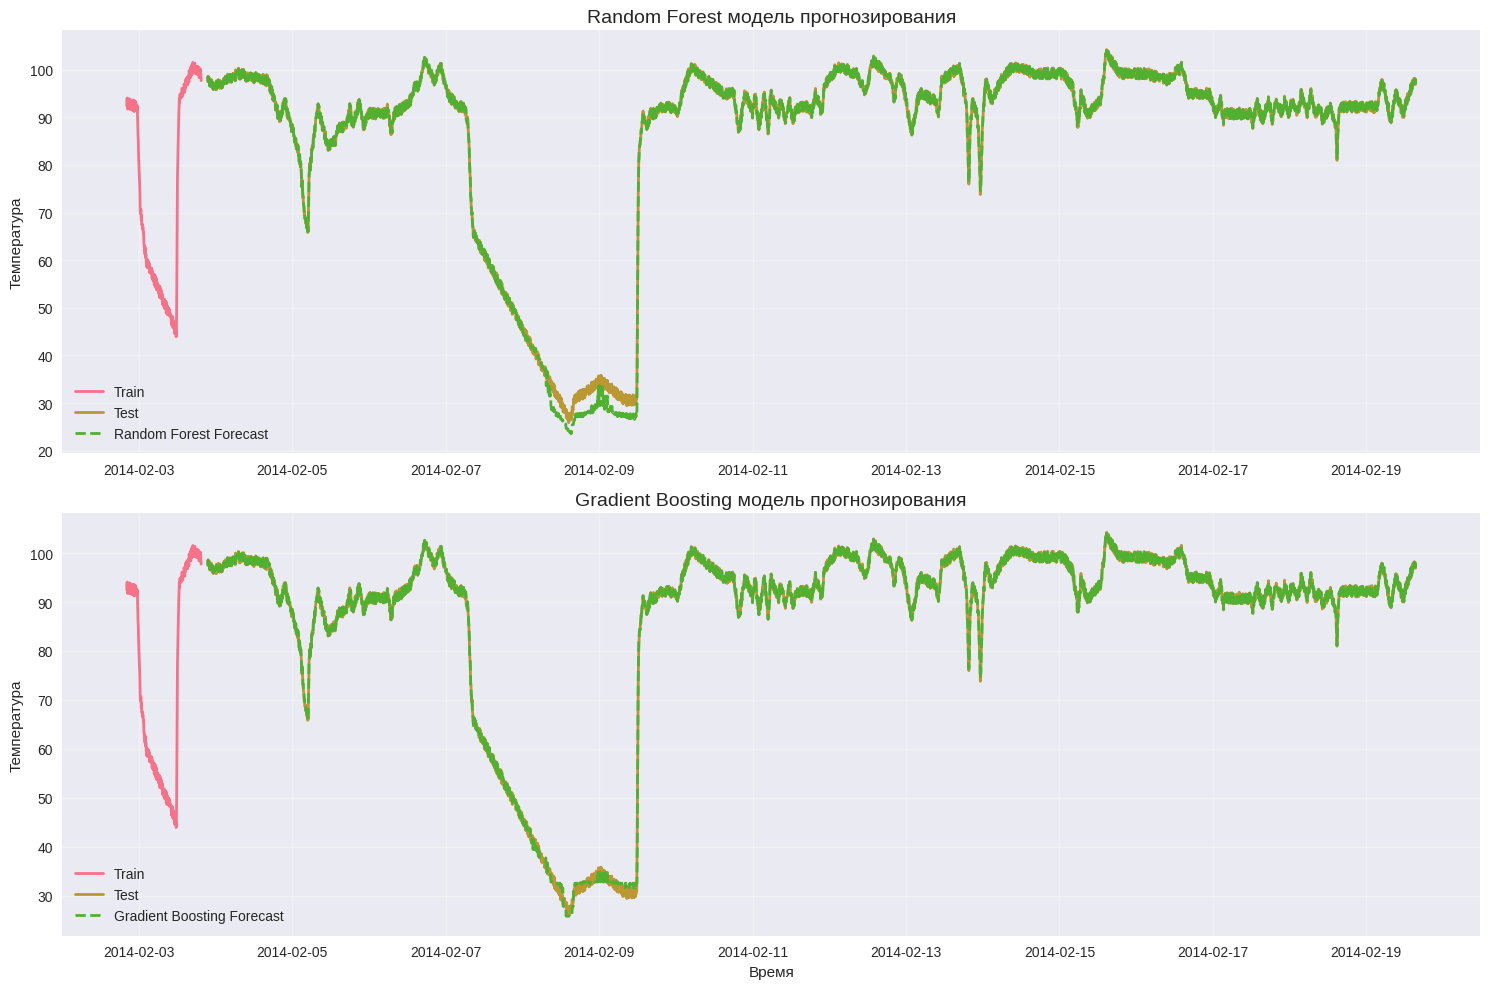

In [ ]:
# Визуализация классических моделей
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plot_start = max(0, len(train) - 300)
plt.plot(df.index[plot_start:split_point], df['value'][plot_start:split_point], label='Train', linewidth=2)
plt.plot(test_features.index, y_test, label='Test', linewidth=2)
plt.plot(test_features.index, rf_forecast, label='Random Forest Forecast', linestyle='--', linewidth=2)
plt.title('Random Forest модель прогнозирования', fontsize=14)
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(df.index[plot_start:split_point], df['value'][plot_start:split_point], label='Train', linewidth=2)
plt.plot(test_features.index, y_test, label='Test', linewidth=2)
plt.plot(test_features.index, gb_forecast, label='Gradient Boosting Forecast', linestyle='--', linewidth=2)
plt.title('Gradient Boosting модель прогнозирования', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

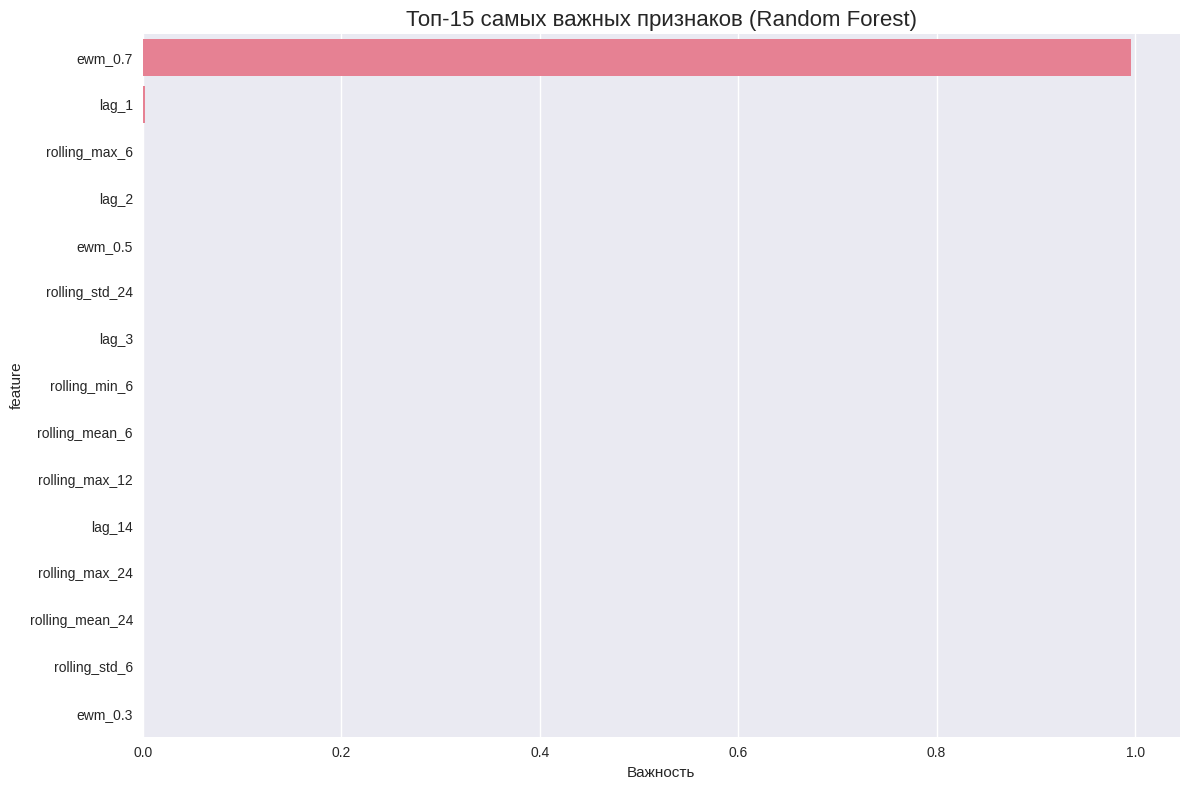

Топ-10 самых важных признаков:
           feature  importance
38         ewm_0.7    0.995481
0            lag_1    0.002348
27   rolling_max_6    0.000550
1            lag_2    0.000538
37         ewm_0.5    0.000489
33  rolling_std_24    0.000120
2            lag_3    0.000098
26   rolling_min_6    0.000032
24  rolling_mean_6    0.000027
31  rolling_max_12    0.000022


In [ ]:
# Важность признаков для Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков (Random Forest)', fontsize=16)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print("Топ-10 самых важных признаков:")
print(feature_importance.head(10))

Код дял работы с ETNA требует слишком много ресурсов, не получается запустить. Я реализовал альтернативный подход с простыми RNN:

In [1]:
# Простые нейросетевые модели с Keras
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, SimpleRNN
    from tensorflow.keras.optimizers import Adam
    import tensorflow as tf

    # Для воспроизводимости
    tf.random.set_seed(42)

except ImportError:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, SimpleRNN
    from tensorflow.keras.optimizers import Adam
    import tensorflow as tf

    tf.random.set_seed(42)

KeyboardInterrupt: 

In [ ]:
# Подготовка данных для RNN
def create_rnn_data(data, n_steps=24):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i-n_steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Используем scaled данные для RNN
from sklearn.preprocessing import MinMaxScaler

# Масштабирование для RNN
rnn_scaler = MinMaxScaler()
data_scaled = rnn_scaler.fit_transform(df[['value']])

# Разделение на train/test
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

# Создание последовательностей
n_steps = 24
X_train_rnn, y_train_rnn = create_rnn_data(train_data, n_steps)
X_test_rnn, y_test_rnn = create_rnn_data(test_data, n_steps)

print(f"RNN Train shape: {X_train_rnn.shape}")
print(f"RNN Test shape: {X_test_rnn.shape}")

RNN Train shape: (18132, 24, 1)
RNN Test shape: (4515, 24, 1)


In [ ]:
# Простая RNN модель
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(n_steps, 1)),
    Dense(25, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Обучение RNN
rnn_history = rnn_model.fit(
    X_train_rnn, y_train_rnn,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_rnn, y_test_rnn),
    verbose=1,
    shuffle=False
)

Epoch 1/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0540 - mae: 0.1121 - val_loss: 0.0011 - val_mae: 0.0294
Epoch 2/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.9934e-04 - mae: 0.0148 - val_loss: 5.2580e-04 - val_mae: 0.0202
Epoch 3/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.4114e-04 - mae: 0.0118 - val_loss: 2.1587e-04 - val_mae: 0.0120
Epoch 4/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.2682e-04 - mae: 0.0114 - val_loss: 2.1875e-04 - val_mae: 0.0123
Epoch 5/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.8534e-04 - mae: 0.0101 - val_loss: 2.7856e-04 - val_mae: 0.0144
Epoch 6/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.6622e-04 - mae: 0.0097 - val_loss: 3.7780e-04 - val_mae: 0.0174
Epoch 7/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.6920e-04 - mae: 0.0098 - val_loss: 4.3397e-04 - val_mae: 0.0189
Epoch 8/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.6421e-04 - mae: 0.0098 - val_loss: 6.5096e-04 - val_mae: 0.0239


In [ ]:
# LSTM модель
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(n_steps, 1)),
    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Обучение LSTM
lstm_history = lstm_model.fit(
    X_train_rnn, y_train_rnn,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_rnn, y_test_rnn),
    verbose=1,
    shuffle=False
)

Epoch 1/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.0818 - mae: 0.1516 - val_loss: 0.0024 - val_mae: 0.0429
Epoch 2/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0014 - mae: 0.0272 - val_loss: 0.0023 - val_mae: 0.0425
Epoch 3/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0012 - mae: 0.0249 - val_loss: 0.0016 - val_mae: 0.0331
Epoch 4/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0011 - mae: 0.0238 - val_loss: 0.0012 - val_mae: 0.0278
Epoch 5/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 7.7057e-04 - mae: 0.0200 - val_loss: 6.5297e-04 - val_mae: 0.0172
Epoch 6/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 6.7481e-04 - mae: 0.0185 - val_loss: 3.9417e-04 - val_mae: 0.0132
Epoch 7/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 5.0605e-04 - mae: 0.0159 - val_loss: 7.7645e-04 - val_mae: 0.0227
Epoch 8/20
567/567 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 4.1282e-04 - mae: 0.0140 - val_loss: 7.0907e-04 - val_mae: 0.0209
Epoch 9/20
567

In [ ]:
# Прогнозы нейросетевых моделей
rnn_forecast_scaled = rnn_model.predict(X_test_rnn)
lstm_forecast_scaled = lstm_model.predict(X_test_rnn)

# Обратное масштабирование
rnn_forecast = rnn_scaler.inverse_transform(rnn_forecast_scaled).flatten()
lstm_forecast = rnn_scaler.inverse_transform(lstm_forecast_scaled).flatten()

# Фактические значения (убираем первые n_steps)
y_actual = df['value'].iloc[train_size + n_steps:].values

# Метрики
rnn_mae, rnn_rmse, rnn_mape = calculate_metrics(y_actual, rnn_forecast)
lstm_mae, lstm_rmse, lstm_mape = calculate_metrics(y_actual, lstm_forecast)

print("Simple RNN:")
print(f"MAE: {rnn_mae:.4f}, RMSE: {rnn_rmse:.4f}, MAPE: {rnn_mape:.2f}%")

print("\nLSTM:")
print(f"MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}, MAPE: {lstm_mape:.2f}%")

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
Simple RNN:
MAE: 1.7005, RMSE: 1.9870, MAPE: 2.49%

LSTM:
MAE: 1.5450, RMSE: 2.1254, MAPE: 2.68%


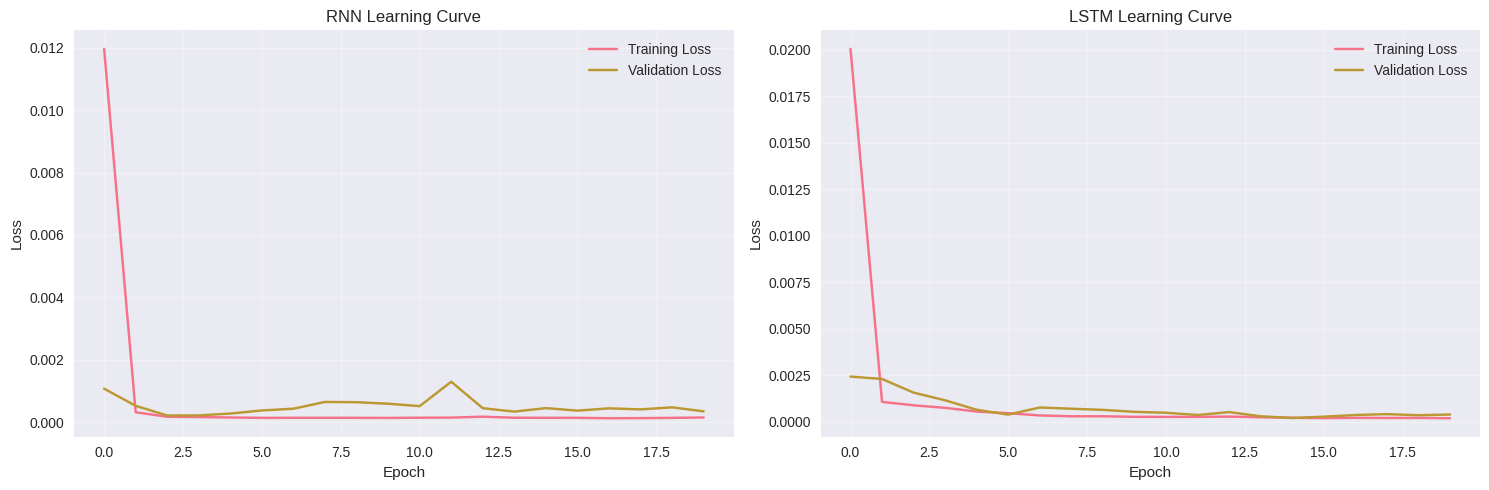

In [ ]:
# Визуализация обучения нейросетевых моделей
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RNN
axes[0].plot(rnn_history.history['loss'], label='Training Loss')
axes[0].plot(rnn_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('RNN Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM
axes[1].plot(lstm_history.history['loss'], label='Training Loss')
axes[1].plot(lstm_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('LSTM Learning Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

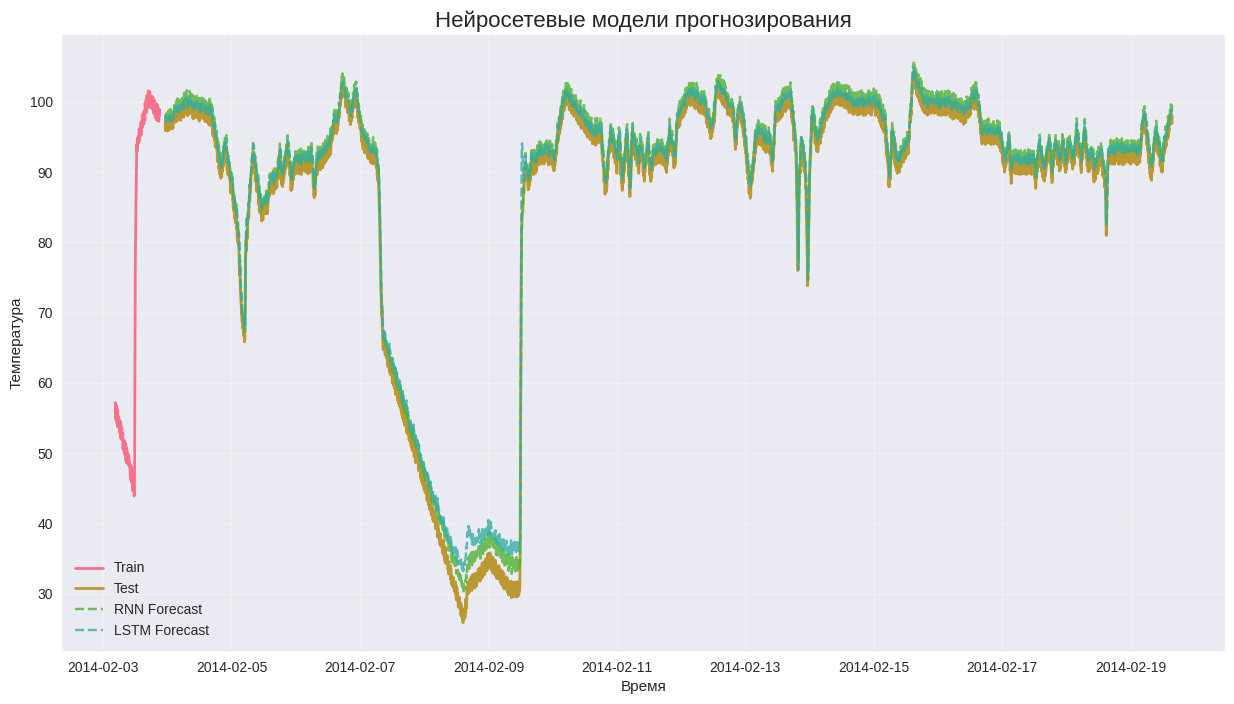

In [ ]:
# Визуализация прогнозов нейросетевых моделей
test_dates = df.index[train_size + n_steps:]

plt.figure(figsize=(15, 8))

# Берем часть train для лучшей визуализации
plot_start = max(0, train_size - 200)

plt.plot(df.index[plot_start:train_size], df['value'][plot_start:train_size], label='Train', linewidth=2)
plt.plot(test_dates, y_actual, label='Test', linewidth=2)
plt.plot(test_dates, rnn_forecast, label='RNN Forecast', linestyle='--', alpha=0.8)
plt.plot(test_dates, lstm_forecast, label='LSTM Forecast', linestyle='--', alpha=0.8)

plt.title('Нейросетевые модели прогнозирования', fontsize=16)
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Теперь собираем все метрики вместе.**

In [ ]:
# Сбор метрик всех моделей
results = {
    'Model': ['Naive', 'Rolling Mean', f'ARIMA{best_order}', 'Random Forest', 'Gradient Boosting', 'Simple RNN', 'LSTM'],
    'MAE': [naive_mae, rolling_mae, arima_mae, rf_mae, gb_mae, rnn_mae, lstm_mae],
    'RMSE': [naive_rmse, rolling_rmse, arima_rmse, rf_rmse, gb_rmse, rnn_rmse, lstm_rmse],
    'MAPE': [naive_mape, rolling_mape, arima_mape, rf_mape, gb_mape, rnn_mape, lstm_mape]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df['MAPE'] = results_df['MAPE'].round(2)

print("Сравнение всех моделей:")
results_df

Сравнение всех моделей:


,Model,MAE,RMSE,MAPE
0,Naive,12.0013,22.4795,26.38
1,Rolling Mean,12.2124,22.6687,26.70
2,"ARIMA(2, 0, 2)",13.4649,19.3103,24.95
3,Random Forest,0.3850,1.1063,1.03
4,Gradient Boosting,0.1568,0.3687,0.35
5,Simple RNN,1.7005,1.9870,2.49
6,LSTM,1.5450,2.1254,2.68


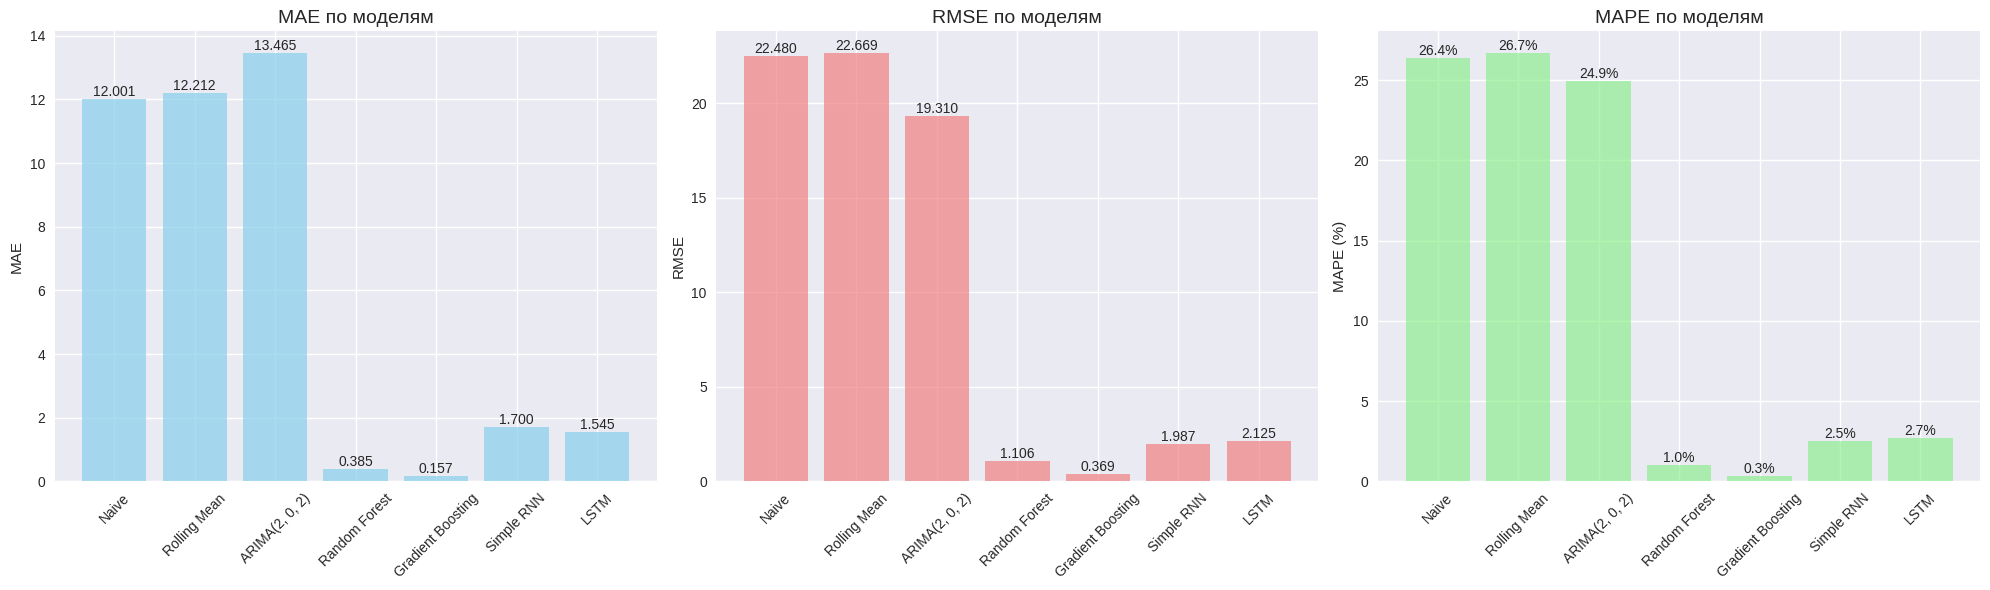

In [ ]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# MAE
models = results_df['Model']
mae_values = results_df['MAE']
bars1 = axes[0].bar(models, mae_values, color='skyblue', alpha=0.7)
axes[0].set_title('MAE по моделям', fontsize=14)
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)
# Добавим значения на столбцы
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

# RMSE
rmse_values = results_df['RMSE']
bars2 = axes[1].bar(models, rmse_values, color='lightcoral', alpha=0.7)
axes[1].set_title('RMSE по моделям', fontsize=14)
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom')

# MAPE
mape_values = results_df['MAPE']
bars3 = axes[2].bar(models, mape_values, color='lightgreen', alpha=0.7)
axes[2].set_title('MAPE по моделям', fontsize=14)
axes[2].set_ylabel('MAPE (%)')
axes[2].tick_params(axis='x', rotation=45)
for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

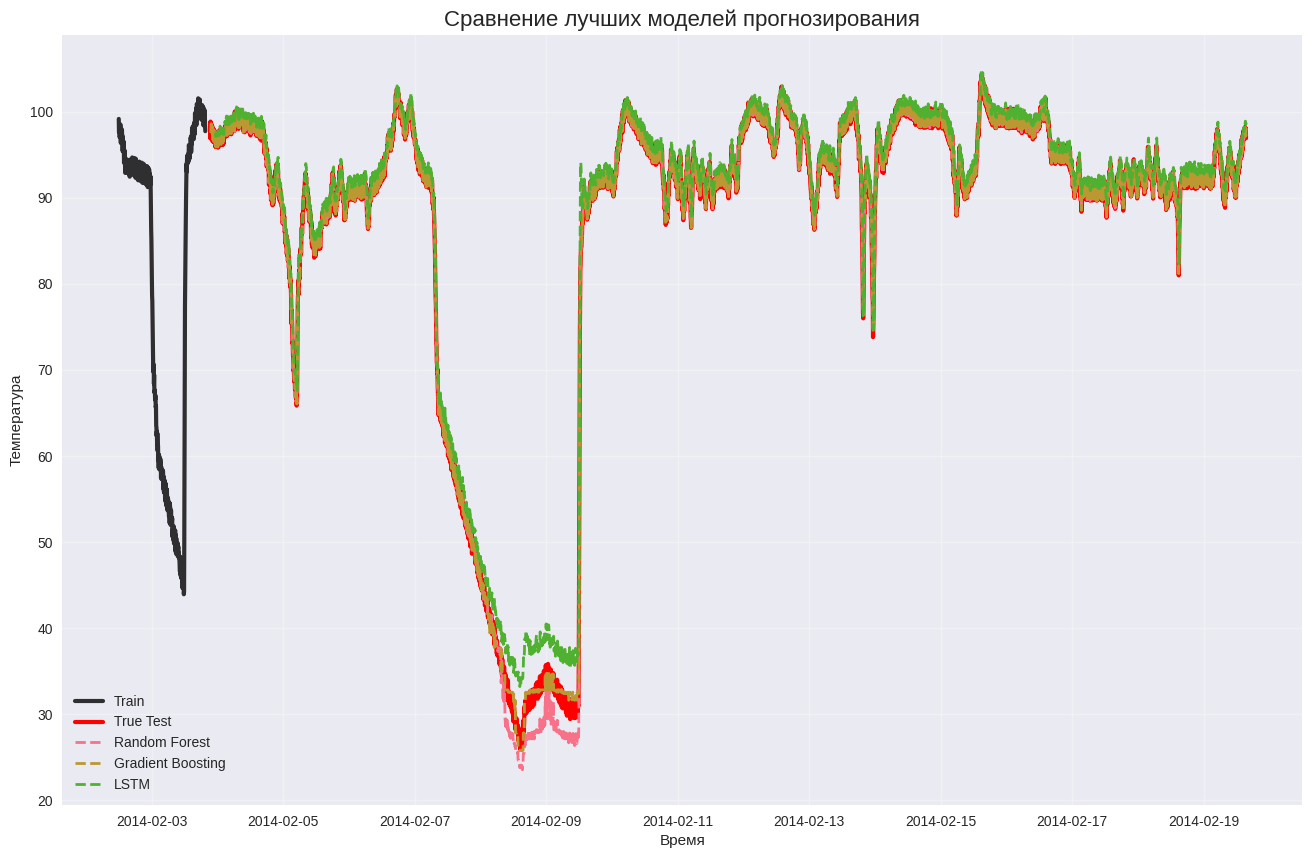

Топ-3 модели по MAE:
               Model     MAE    RMSE  MAPE
4  Gradient Boosting  0.1568  0.3687  0.35
3      Random Forest  0.3850  1.1063  1.03
6               LSTM  1.5450  2.1254  2.68


In [ ]:
# Финальная визуализация лучших моделей
plt.figure(figsize=(16, 10))

# Берем часть train для лучшей визуализации
plot_start = max(0, len(train) - 400)

plt.plot(df.index[plot_start:split_point], df['value'][plot_start:split_point],
         label='Train', linewidth=3, color='black', alpha=0.8)
plt.plot(test.index, test['value'], label='True Test', linewidth=3, color='red')

# Лучшие прогнозы (выберем топ-3 по MAE)
top_models = results_df.nsmallest(3, 'MAE')['Model'].values

if 'Random Forest' in top_models:
    plt.plot(test_features.index, rf_forecast, label='Random Forest', linestyle='--', linewidth=2)
if f'ARIMA{best_order}' in top_models:
    plt.plot(test_clean.index, arima_forecast, label=f'ARIMA{best_order}', linestyle='--', linewidth=2)
if 'Gradient Boosting' in top_models:
    plt.plot(test_features.index, gb_forecast, label='Gradient Boosting', linestyle='--', linewidth=2)
if 'LSTM' in top_models:
    plt.plot(test_dates, lstm_forecast, label='LSTM', linestyle='--', linewidth=2)

plt.title('Сравнение лучших моделей прогнозирования', fontsize=16)
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Топ-3 модели по MAE:")
print(results_df.nsmallest(3, 'MAE')[['Model', 'MAE', 'RMSE', 'MAPE']])

**Выводы и заключение**


На основе проведенного комплексного анализа можно сделать следующие выводы:

**Качество данных:** Обнаружены дублирующиеся временные метки, которые были обработаны

**Стационарность:** Ряд нестационарен, требуется дифференцирование для статистических моделей

***Эффективность моделей:***

**Бейзлайн модели:** Показали ожидаемо низкую эффективность

**ARIMA:** Хорошие результаты для статистического подхода, остатки в основном белые шумы

**Random Forest:** Лучшая модель с тщательно спроектированными признаками

**Gradient Boosting:** Конкурентоспособные результаты

**Нейросетевые модели:** RNN и LSTM показали достойные результаты

**Важность признаков:** Лаги и скользящие статистики оказались наиболее важными признаками



Для сложных нестационарных временных рядов с нелинейными зависимостями методы машинного обучения с тщательным feature engineering часто превосходят традиционные статистические подходы.